# Naive Bayes Calibration — CV on Train Set (2 subsets)

**Strategy:** 2-subset split (train / test).

- **Train** — Naive Bayes is fitted here; isotonic calibration is fitted via `CalibratedClassifierCV(cv=5)` on the same split (cross-validated, so no leakage).
- **Test** — both raw and calibrated probabilities are evaluated here.

This approach is appropriate when data is limited: cross-validation squeezes calibration out of the training set without reserving a separate cal split.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from feature_engine.encoding import OrdinalEncoder
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV
from sklearn.datasets import fetch_openml
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

SEED = 42

In [2]:
data = fetch_openml(name="bank-marketing", version=1, as_frame=True, parser="auto")
X = OrdinalEncoder(encoding_method="arbitrary").fit_transform(data.data)
y = (data.target == "2").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y,
)

## Train raw and calibrated models

Naive Bayes assumes feature independence and produces poorly calibrated probabilities — it is a classic example of a model that benefits from post-hoc calibration.

The calibrated model is trained with `CalibratedClassifierCV(cv=5)`, which fits the base GNB on 4 folds and calibrates on the hold-out fold, repeated 5 times. This avoids leakage while staying within the training set.

In [3]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

gnb = GaussianNB().fit(X_train_sc, y_train)
probs_raw = gnb.predict_proba(X_test_sc)[:, 1]

cal_gnb = CalibratedClassifierCV(GaussianNB(), method="isotonic", cv=5)
cal_gnb.fit(X_train_sc, y_train)
probs_cal = cal_gnb.predict_proba(X_test_sc)[:, 1]

## Performance

In [4]:
pd.DataFrame({
    "ROC-AUC":     [roc_auc_score(y_test, probs_raw),     roc_auc_score(y_test, probs_cal)],
    "Brier score": [brier_score_loss(y_test, probs_raw),  brier_score_loss(y_test, probs_cal)],
    "Log-loss":    [log_loss(y_test, probs_raw),          log_loss(y_test, probs_cal)],
}, index=["Raw NB", "Calibrated NB"]).round(4)

,ROC-AUC,Brier score,Log-loss
Raw NB,0.8290,0.1263,0.6618
Calibrated NB,0.8303,0.0824,0.2778


## Calibration curves and probability histograms

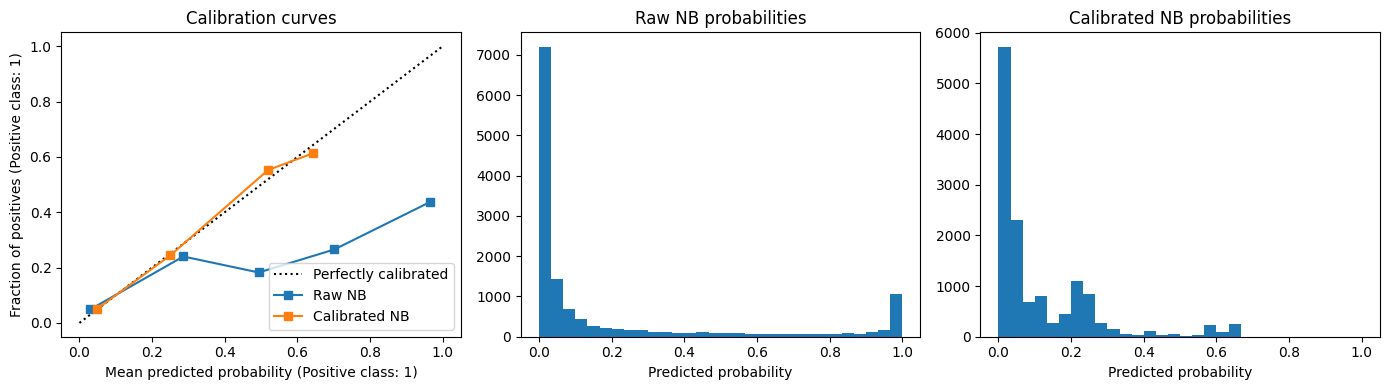

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

CalibrationDisplay.from_predictions(y_test, probs_raw, ax=axes[0], label="Raw NB")
CalibrationDisplay.from_predictions(y_test, probs_cal, ax=axes[0], label="Calibrated NB")
axes[0].set_title("Calibration curves")

axes[1].hist(probs_raw, bins=30, range=(0, 1))
axes[1].set_title("Raw NB probabilities")
axes[1].set_xlabel("Predicted probability")

axes[2].hist(probs_cal, bins=30, range=(0, 1))
axes[2].set_title("Calibrated NB probabilities")
axes[2].set_xlabel("Predicted probability")

plt.tight_layout()
outputdir="../../mlid-book/resources/ch3/ch3-nb-cv.png"
plt.savefig(outputdir, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()